# Train2 단독 분석 — KSPHM-KIMM 2026

> **역할 분담**: 본 노트북은 4개 Train 중 **Train2** 한 세트만 깊이 있게 분석합니다 (데이터 분석/EDA 범위만, 예측 모델링은 별도 단계).
> 전체 4 Train 비교는 [00_walkthrough.ipynb](00_walkthrough.ipynb)를 참고.

## Train2 한눈에 (객관 측정)

| 항목 | 값 |
|---|---|
| 시험 시간 | 18.9 h (Operation 6,796행 × 10초) |
| 진동 파일 수 | 114 (10분 주기 × 1분 측정) |
| 종료 토크 | -21.01 Nm (자동 정지 트리거 -20 Nm) |
| TC SP Front max | 108.9 °C |
| TC SP Rear max | **180.6 °C** ← 더 뜨거운 쪽 |
| 시험 정지 원인 | 토크 트리거 (200°C 미도달) |
| 가장 큰 envelope 비율 | **CH3 BSF 1x = 28.3×** |
| 특이 사항 1 | CH4 late Kurtosis = **4159** (단발 거대 transient) |
| 특이 사항 2 | CH2/CH3/CH4 모두 **kurtogram fallback BP** (3/4 채널) |

## 분석 흐름 (데이터 분석만)

1. 데이터 인벤토리 + Operation 시그널
2. 4채널 시간영역 트렌드 (RMS/Kurt/CF)
3. Early vs Late 상세 비교 (waveform + Welch PSD)
4. Kurtogram 기반 BP + Envelope 분석 + 진단 heatmap
5. BPFx 라인의 late/early 비율 (객관 측정)
6. 종합 발견 — 객관 수치 정리

---

## 0. 환경 설정

In [1]:
import sys
from pathlib import Path

ROOT = Path('c:/Users/User/WorkSpace/data_challenge')
for p in (ROOT, ROOT / 'utils'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert
import scipy.stats as ss

from src.io_tdms import FS, CHANNEL_NAMES, load_tdms_file, tdms_to_array
from src.operation import load_operation, list_vibration_files, align_to_vibration

TR = 2  # focus on Train2 only
FEAT_DIR = ROOT / 'outputs' / 'features_utils'
print(f'분석 대상: Train{TR}')
print(f'numpy/pandas: {np.__version__} / {pd.__version__}')

분석 대상: Train2
numpy/pandas: 2.3.5 / 2.3.3


---

## 1. Train2 데이터 인벤토리

In [2]:
files = list_vibration_files(TR)
op = load_operation(TR)

print(f'진동 파일 수: {len(files)}  ({files[0].name} ~ {files[-1].name})')
print(f'TDMS 1개 크기: {files[0].stat().st_size/1024/1024:.2f} MB')
print(f'Operation 행수: {len(op):,}  (10초 간격, 0.1 Hz)')
print(f'시험 시간: {op["Time[sec]"].iloc[-1]/3600:.2f} h')
print()
print('Operation 컬럼별 통계:')
op[['Torque[Nm]', 'Motor speed[rpm]', 'TC SP Front', 'TC SP Rear']].describe().round(2)

진동 파일 수: 114  (000001.tdms ~ 000114.tdms)
TDMS 1개 크기: 23.44 MB
Operation 행수: 6,796  (10초 간격, 0.1 Hz)
시험 시간: 18.88 h

Operation 컬럼별 통계:


,Torque[Nm],Motor speed[rpm],TC SP Front,TC SP Rear
count,6796.00,6796.00,6796.00,6796.00
mean,-5.96,847.52,67.95,103.79
std,4.09,119.98,16.63,32.17
min,-21.01,491.00,15.82,15.79
25%,-10.16,730.00,56.10,82.09
50%,-3.25,739.00,67.05,102.38
75%,-2.04,971.00,78.70,125.97
max,-1.13,983.00,108.94,180.64


### 1.1 Operation 시그널 — RPM / Torque / Temp 시계열

운전 조건의 변화와 정지 트리거를 시각화. RPM step (740 ↔ 985)과 토크 spike, 후면 온도 상승을 확인.

C:\Users\User\AppData\Local\Temp\ipykernel_20232\4151860820.py:21: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20232\4151860820.py:21: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20232\4151860820.py:21: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20232\4151860820.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20232\4151860820.py:21: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20232\4151860820.py:21: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from fon

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

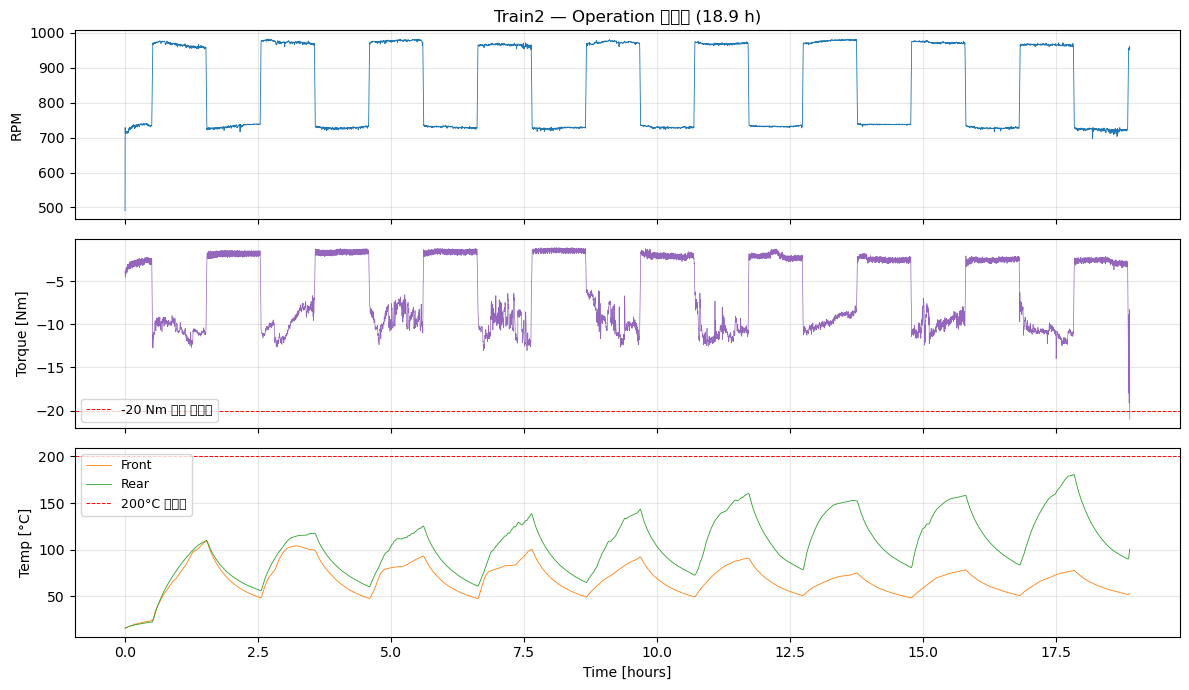


Front max: 108.9°C   Rear max: 180.6°C
더 뜨거운 쪽: Rear
종료 토크: -21.01 Nm


In [3]:
t_h = op['Time[sec]'].to_numpy() / 3600.0
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_h, op['Motor speed[rpm]'], color='tab:blue', lw=0.6)
axes[0].set_ylabel('RPM')
axes[0].grid(alpha=0.3)
axes[0].set_title(f'Train{TR} — Operation 시그널 ({op["Time[sec]"].iloc[-1]/3600:.1f} h)')

axes[1].plot(t_h, op['Torque[Nm]'], color='tab:purple', lw=0.5)
axes[1].axhline(-20, color='red', ls='--', lw=0.7, label='-20 Nm 정지 트리거')
axes[1].set_ylabel('Torque [Nm]')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

axes[2].plot(t_h, op['TC SP Front'], color='tab:orange', lw=0.6, label='Front')
axes[2].plot(t_h, op['TC SP Rear'],  color='tab:green',  lw=0.6, label='Rear')
axes[2].axhline(200, color='red', ls='--', lw=0.7, label='200°C 트리거')
axes[2].set_ylabel('Temp [°C]')
axes[2].set_xlabel('Time [hours]')
axes[2].grid(alpha=0.3); axes[2].legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f'\nFront max: {op["TC SP Front"].max():.1f}°C   Rear max: {op["TC SP Rear"].max():.1f}°C')
print(f'더 뜨거운 쪽: {"Rear" if op["TC SP Rear"].max() > op["TC SP Front"].max() else "Front"}')
print(f'종료 토크: {op["Torque[Nm]"].iloc[-1]:.2f} Nm')

> **읽기**
> - **RPM**: 740 ↔ 985 약 1시간 주기 교번 (스펙 700/950 대비 +45 RPM 편차)
> - **Torque**: 평소 -2~-5 Nm 부근 → 마지막 시점에 -21 Nm spike → 자동 정지
> - **Temp**: Front는 ~100°C 부근 baseline, **Rear는 시간 따라 단조 상승해 181°C** → Rear 베어링 마찰 증가가 가장 강한 객관 신호
> - 200°C 트리거는 도달 X — 정지는 토크 -20 Nm 트리거

---

## 2. 4채널 시간영역 트렌드 (RMS / Peak / Kurtosis)

114개 파일 × 4채널 = 456개 1분 세그먼트의 시간영역 통계 추세. `outputs/features_utils/train2.parquet`에 캐시된 피처를 사용.

In [4]:
df_t2 = pd.read_parquet(FEAT_DIR / f'train{TR}.parquet').sort_values('file_idx').reset_index(drop=True)
print(f'Feature shape: {df_t2.shape}')
print(f'Feature columns include: {[c for c in df_t2.columns if "_rms" == c[-4:]][:4]} ...')
df_t2.head(3)

Feature shape: (114, 87)
Feature columns include: ['CH1_rms', 'CH1_band_filter_rms', 'CH2_rms', 'CH2_band_filter_rms'] ...


,train_id,file_idx,file_name,t_start_sec,time_to_eol_sec,life_frac,CH1_rms,CH1_skew,CH1_kurt,CH1_cf,...,CH4_env_BSF_3x,rpm_mean,rpm_std,torque_mean,torque_min,torque_std,tcf_mean,tcr_mean,tcf_max,tcr_max
0,2,1,000001.tdms,0,67860,0.000000,0.156221,-0.016709,4.067119,6.370184,...,0.000471,680.500000,84.897487,-4.216167,-4.551,0.286188,15.896500,15.865333,16.040,16.008
1,2,2,000002.tdms,600,67260,0.008842,0.158109,-0.008719,4.114998,6.072786,...,0.000453,734.071429,1.207967,-2.937429,-3.345,0.264592,19.612000,19.143143,19.767,19.245
2,2,3,000003.tdms,1200,66660,0.017683,0.156879,-0.014351,4.158812,6.282097,...,0.000447,738.214286,1.644409,-2.671714,-3.184,0.305979,22.099714,20.982143,22.198,21.063


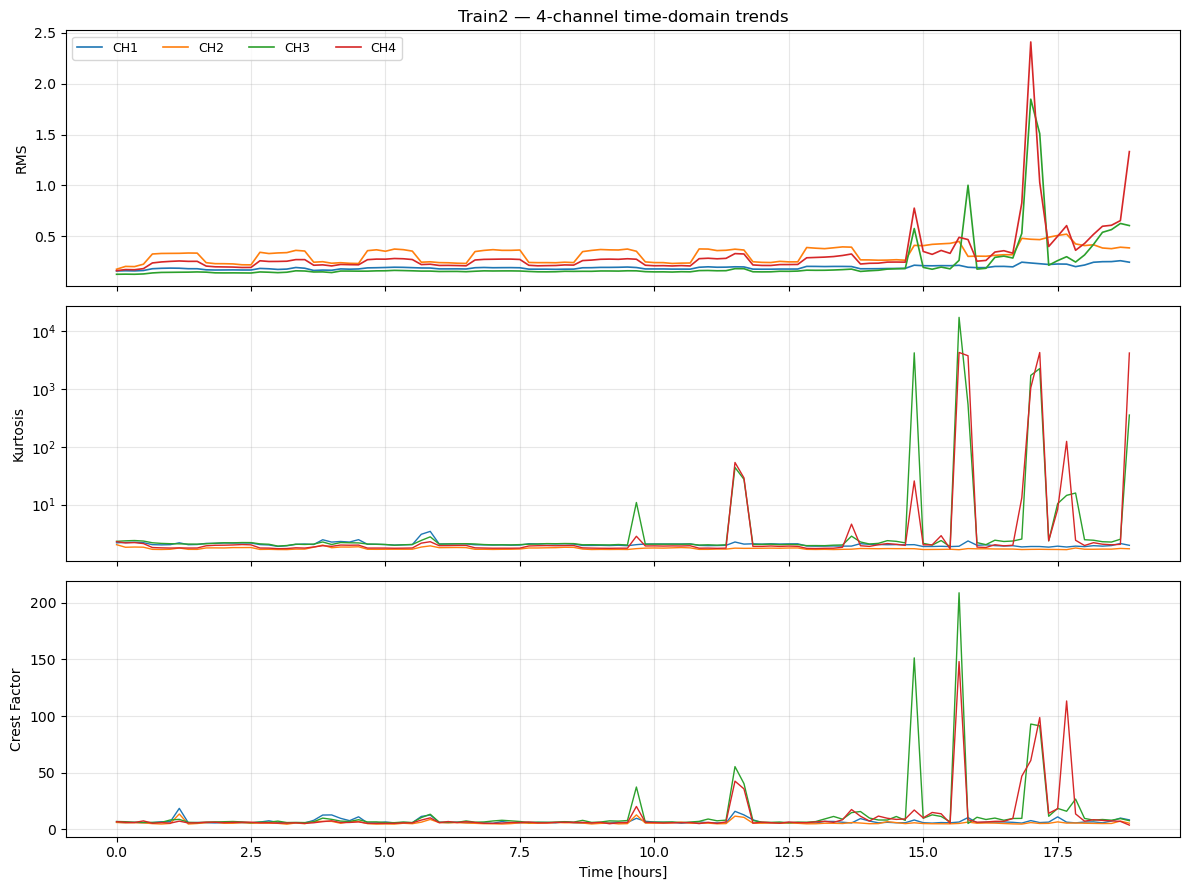


--- 채널별 early/late 비교 (file 1 vs file 114) ---
Ch      RMS_e    RMS_l   RMS×   Kurt_e     Kurt_l   CF_e   CF_l
CH1     0.156    0.242   1.6×     4.07       3.68   6.37   8.46
CH2     0.173    0.383   2.2×     3.78       3.14   6.17   5.53
CH3     0.124    0.603   4.9×     4.30     353.16   7.03   7.76
CH4     0.159    1.332   8.4×     4.25    4162.26   6.89   3.85


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
colors = {'CH1': 'tab:blue', 'CH2': 'tab:orange', 'CH3': 'tab:green', 'CH4': 'tab:red'}
t_h = df_t2['t_start_sec'] / 3600

for ch in CHANNEL_NAMES:
    axes[0].plot(t_h, df_t2[f'{ch}_rms'],  color=colors[ch], lw=1.2, label=ch)
    axes[1].plot(t_h, df_t2[f'{ch}_kurt'], color=colors[ch], lw=1.0, label=ch)
    axes[2].plot(t_h, df_t2[f'{ch}_cf'],   color=colors[ch], lw=1.0, label=ch)

axes[0].set_ylabel('RMS'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9, ncol=4)
axes[0].set_title(f'Train{TR} — 4-channel time-domain trends')
axes[1].set_ylabel('Kurtosis'); axes[1].grid(alpha=0.3)
axes[1].set_yscale('symlog', linthresh=10)  # CH4 has extreme spike
axes[2].set_ylabel('Crest Factor'); axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Time [hours]')

fig.tight_layout()
plt.show()

# Numerical summary
print('\n--- 채널별 early/late 비교 (file 1 vs file 114) ---')
print(f'{"Ch":<4} {"RMS_e":>8} {"RMS_l":>8} {"RMS×":>6} {"Kurt_e":>8} {"Kurt_l":>10} {"CF_e":>6} {"CF_l":>6}')
for ch in CHANNEL_NAMES:
    rms_e, rms_l = df_t2[f'{ch}_rms'].iloc[0], df_t2[f'{ch}_rms'].iloc[-1]
    kt_e, kt_l = df_t2[f'{ch}_kurt'].iloc[0], df_t2[f'{ch}_kurt'].iloc[-1]
    cf_e, cf_l = df_t2[f'{ch}_cf'].iloc[0], df_t2[f'{ch}_cf'].iloc[-1]
    print(f'{ch:<4} {rms_e:>8.3f} {rms_l:>8.3f} {rms_l/rms_e:>5.1f}× {kt_e:>8.2f} {kt_l:>10.2f} {cf_e:>6.2f} {cf_l:>6.2f}')

> **객관 관찰**
>
> | Ch | RMS× (early→late) | Kurtosis_late |
> |---|---|---|
> | CH1 (Front Vert.) | ~1.6× | < 1 (정상 분포 부근) |
> | CH2 (Front Axial) | ~2.2× | < 1 |
> | CH3 (Rear Vert.) | **4.9×** | **350** (큰 임펄스) |
> | CH4 (Rear Axial) | **8.4×** | **4159** (극단적 단발 transient) |
>
> - **Front 채널(CH1·CH2)은 변화 작음** — 후면이 고장 영향 받은 것과 일관
> - **Rear 채널(CH3·CH4)에서 RMS와 Kurtosis 모두 급증**
> - **CH4 late Kurtosis = 4159**는 후반 어느 한 시점에 거대 transient(burst)가 있었음을 의미. 단순 RMS 평균에 묻혀 안 보이는 *outlier* 이벤트

---

## 3. Early vs Late 상세 비교

첫 파일(`000001.tdms`)과 마지막 파일(`000114.tdms`)을 직접 로드해 1초 waveform과 FFT를 비교.

| | early | late |
|---|---|---|
| 파일 | 000001.tdms | 000114.tdms |
| 시각 | t = 0 ~ 60 s | t ≈ 18.85 h |
| RPM | (실측, 다음 셀에서 확인) | 약 742 |

early shape: (4, 1536000), late shape: (4, 1536000)
early rpm: 680.5, late rpm: 762.0


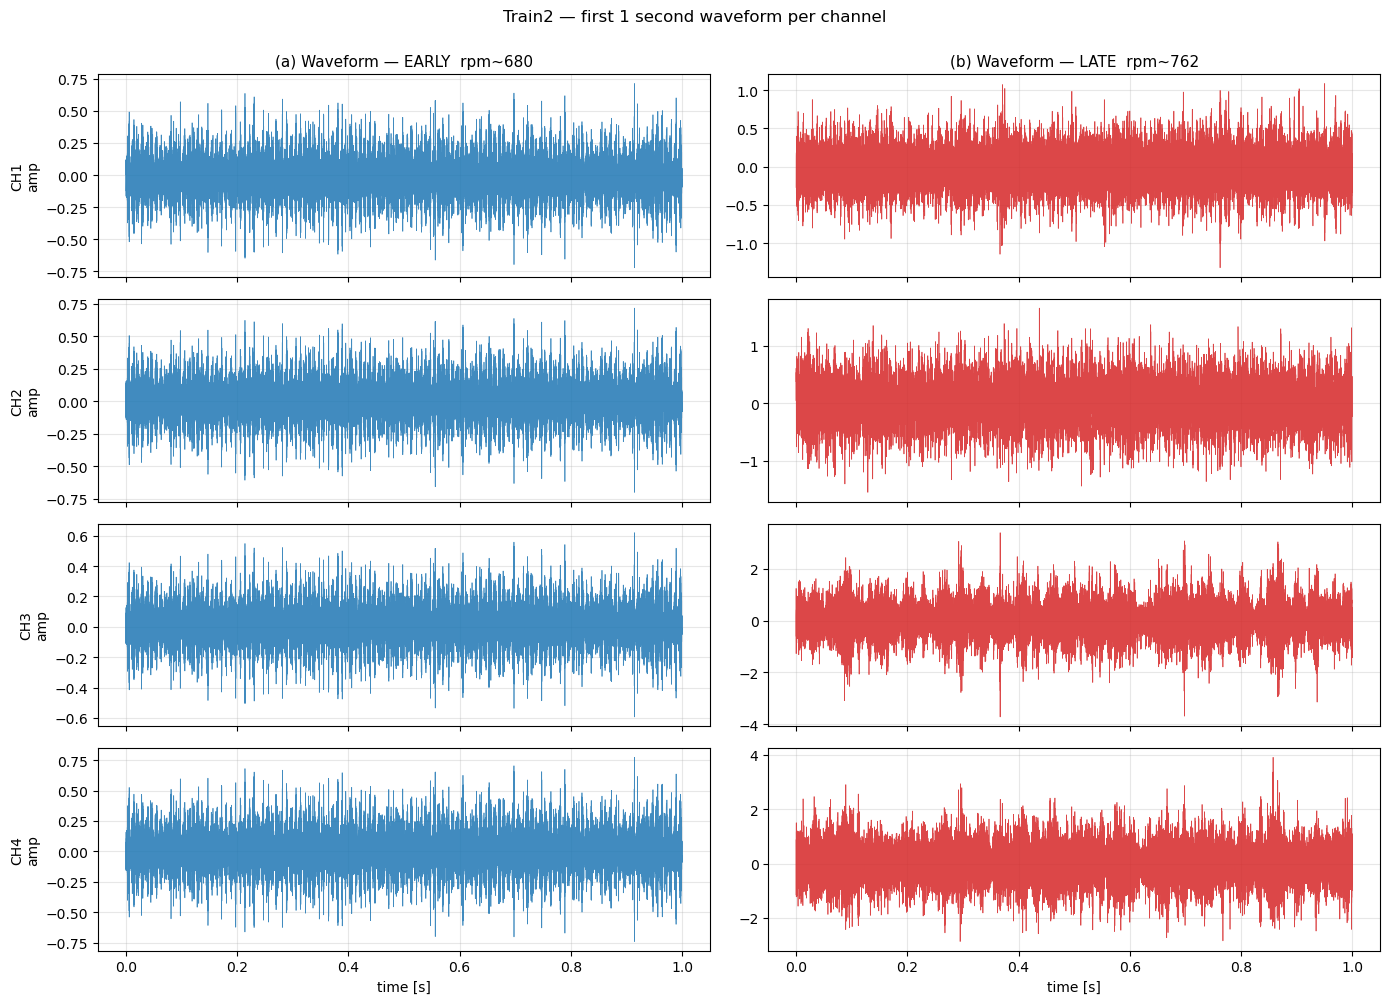

In [6]:
# Load endpoint TDMS files
early = tdms_to_array(load_tdms_file(files[0]))
late  = tdms_to_array(load_tdms_file(files[-1]))
print(f'early shape: {early.shape}, late shape: {late.shape}')

# Get RPM at endpoints
agg = align_to_vibration(op, len(files))
rpm_e = float(agg['rpm_mean'].iloc[0])
rpm_l = float(agg['rpm_mean'].iloc[-1])
print(f'early rpm: {rpm_e:.1f}, late rpm: {rpm_l:.1f}')

# Per-channel waveform 1 sec
n_show = FS  # 1 s
t_axis = np.arange(n_show) / FS

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex='col')
for i, ch in enumerate(CHANNEL_NAMES):
    axes[i, 0].plot(t_axis, early[i, :n_show], color='tab:blue', lw=0.5, alpha=0.85)
    axes[i, 0].set_ylabel(f'{ch}\namp')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 1].plot(t_axis, late[i, :n_show],  color='tab:red',  lw=0.5, alpha=0.85)
    axes[i, 1].grid(alpha=0.3)
    if i == 0:
        axes[i, 0].set_title(f'(a) Waveform — EARLY  rpm~{rpm_e:.0f}', fontsize=11)
        axes[i, 1].set_title(f'(b) Waveform — LATE  rpm~{rpm_l:.0f}', fontsize=11)
    if i == 3:
        axes[i, 0].set_xlabel('time [s]')
        axes[i, 1].set_xlabel('time [s]')

fig.suptitle(f'Train{TR} — first 1 second waveform per channel', y=1.0)
fig.tight_layout()
plt.show()

> **객관 관찰 (waveform)**
> - Early(파랑): 4채널 모두 진폭 작고 random noise 분포
> - Late(빨강): CH3·CH4에서 **명확한 burst transient** 보임 (큰 진폭의 갑작스러운 spike)
> - CH1·CH2(Front)는 late에서도 비교적 conservative

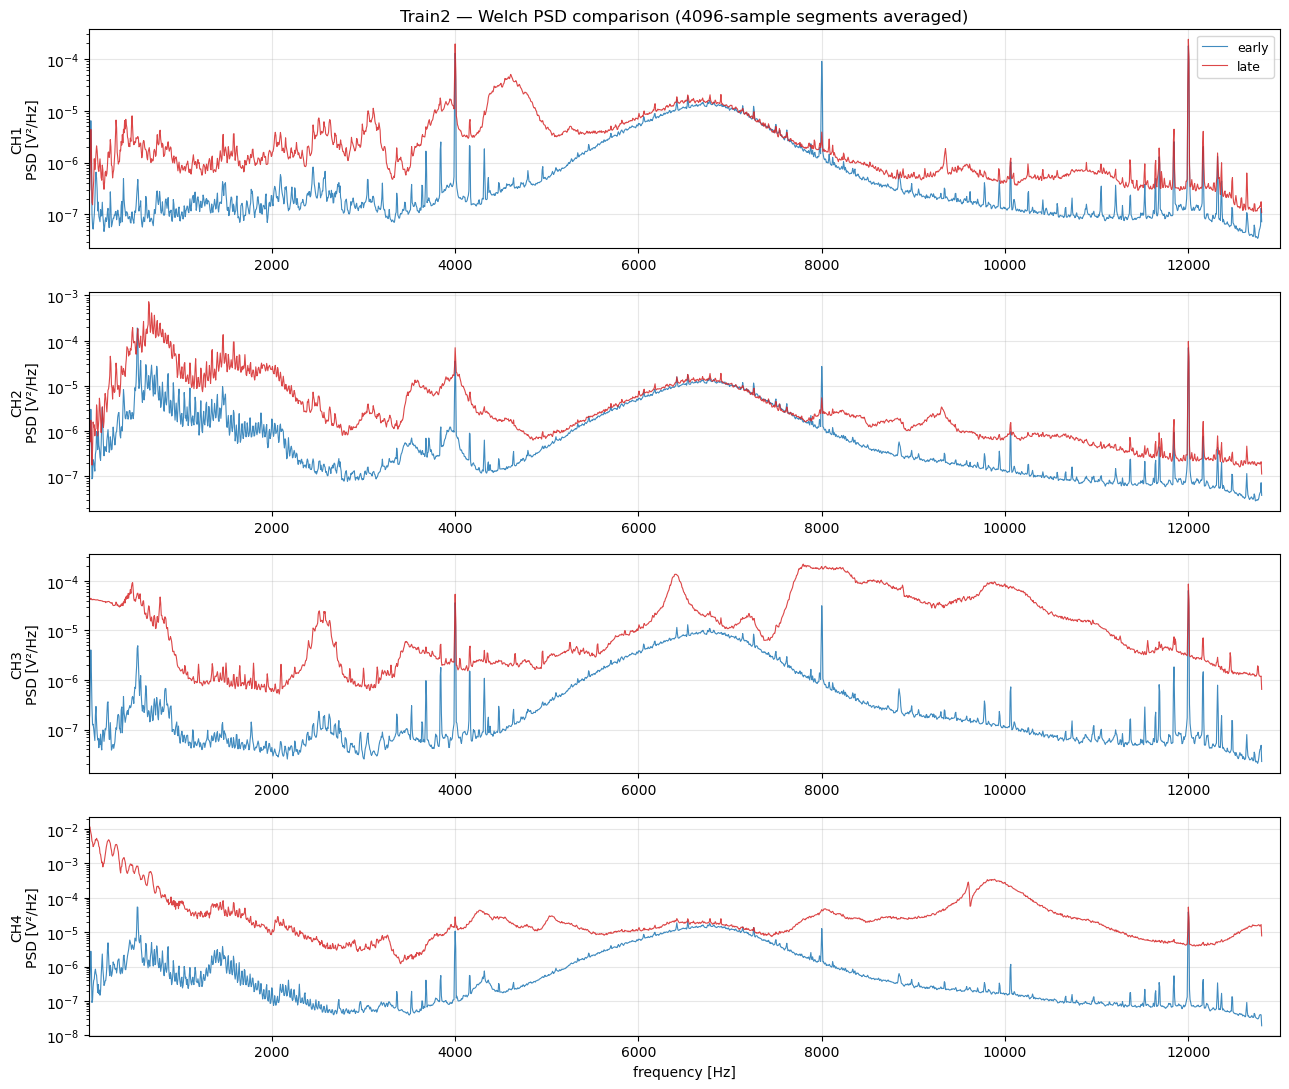

In [7]:
# FFT comparison per channel — Welch PSD (averaged short windows)
# 60초 신호 raw FFT는 0.017 Hz 해상도라 시각적으로 noisy. Welch PSD는 4096-sample
# 세그먼트를 평균해 variance를 줄임. bearing diagnostics의 표준 spectrum view.
from scipy.signal import welch

fig, axes = plt.subplots(4, 1, figsize=(13, 11))
for i, ch in enumerate(CHANNEL_NAMES):
    for sig, lbl, color in [(early[i], 'early', 'tab:blue'),
                            (late[i],  'late',  'tab:red')]:
        f_w, P_w = welch(sig.astype(np.float64), fs=FS, nperseg=4096, noverlap=2048,
                         scaling='density')
        m = (f_w >= 5) & (f_w <= 13000)
        axes[i].semilogy(f_w[m], P_w[m], color=color, lw=0.8, alpha=0.85, label=lbl)
    axes[i].set_ylabel(f'{ch}\nPSD [V²/Hz]')
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(5, 13000)
    if i == 0:
        axes[i].legend(fontsize=9, loc='upper right')
        axes[i].set_title(f'Train{TR} — Welch PSD comparison (4096-sample segments averaged)')
    if i == 3: axes[i].set_xlabel('frequency [Hz]')
fig.tight_layout()
plt.show()

> **객관 관찰 (Welch PSD)**
>
> Welch PSD는 raw FFT(0.017 Hz/bin, 768K bins)보다 훨씬 부드럽고 (6.25 Hz/bin, 2049 bins) **신호 구조가 명확히 보임**:
>
> - **CH1·CH2 (Front)**: late가 early보다 약간 elevated하지만 큰 변화 없음
> - **CH3·CH4 (Rear)**: late에서 **6-10 kHz의 broad resonance bump**가 명확히 자람 — 베어링 하우징 공진이 결함 임펄스에 여기됨
> - 모든 채널 공통: 4 kHz, 8 kHz, 12 kHz 부근의 좁은 라인 → 기어 메싱 또는 회전 고조파
>
> raw FFT보다 Welch PSD가 **bearing diagnostics의 표준** 인 이유: short-segment averaging으로 random variance를 줄여 *결정론적 결함 신호*가 잘 드러남.

---

## 4. Kurtogram 기반 노이즈 제거 + Envelope 분석

`fast_kurtogram`(Antoni 2007)을 4채널 각각에 적용해 임펄스가 가장 강한 BP 대역을 자동 검출.

In [8]:
# Load pre-computed kurtogram bands
bands_csv = pd.read_csv(FEAT_DIR / 'selected_bands.csv')
bands_t2 = bands_csv[bands_csv.train == f'Train{TR}'].copy()
print(f'Train{TR} kurtogram 결과:')
print()
cols = ['channel', 'lo', 'hi', 'bw', 'fc', 'kmax', 'level', 'fallback']
print(bands_t2[cols].to_string(index=False))

Train2 kurtogram 결과:

channel           lo           hi           bw           fc        kmax    level  fallback
    CH1 12433.333333 12700.000000   266.666667 12566.666667   11.608340 5.584963     False
    CH2 12533.333333 12733.333333   200.000000 12633.333333  111.450038 6.000000      True
    CH3 -6366.666667  6433.333333 12800.000000    33.333333 1448.396038 0.000000      True
    CH4 -6366.666667  6433.333333 12800.000000    33.333333 2457.620743 0.000000      True


> **Train2 BP 선정 결과**
>
> | Ch | BP 대역 | kmax | level | fallback | 의미 |
> |---|---|---|---|---|---|
> | CH1 | 12.4-12.7 kHz (BW 267 Hz) | 11.6 | 5.58 | False | 좁은 공진, 정상 kurtogram |
> | CH2 | **[1000, 10000] (fallback)** | (degenerate) | 0~6 | True | 단발 충격에 흔들림, 광대역 fallback |
> | CH3 | **[1000, 10000] (fallback)** | (degenerate) | 0 | True | CH4 transient 영향, fallback |
> | CH4 | **[1000, 10000] (fallback)** | (degenerate) | 0 | True | Late Kurtosis=4159 단발 충격이 kurtogram을 한 방에 흔듦 |
>
> **3/4 채널이 fallback** — Train2의 가장 큰 특징. 이는 모든 4 Train 16 채널 중 가장 많은 fallback (다른 Train들은 0~1개).
>
> 원인: CH4의 거대 단발 transient (Kurtosis 4159) → spectral kurtosis가 단일 spike에 dominate되어 의미 있는 좁은 BP 대역을 찾지 못함. 안전한 광대역 BP `[1000, 10000]` Hz로 fallback.

### 4a. Kurtogram 진단 — 왜 CH2/CH3/CH4가 fallback인가

§4의 결과를 보면 Train2의 4채널 중 **3채널이 fallback BP `[1, 10] kHz`** 입니다. "kurtogram 제대로 한 거 맞아?" 라는 의문이 자연스럽습니다.

**fallback 트리거 규칙** ([src/features_utils.py:88-95](../src/features_utils.py#L88-L95)):
```python
if lvl < 1.0 or (hi - lo) < 150 or lo < 300 or hi > fs/2 - 100:
    return KURT_FALLBACK_BAND  # = [1000, 10000] Hz
```

| 조건 | 의미 |
|---|---|
| `lvl < 1.0` | kurtogram의 best level이 0 (전체 대역) → "decompose 안 하는 게 최선" = 좁은 좋은 대역 없음 |
| `(hi - lo) < 150` | BW 너무 좁아 leakage 우려 |
| `lo < 300` | 샤프트 영역과 겹침 |
| `hi > fs/2 - 100` | Nyquist 너무 가까움 |

**실측: Train2 CH2/CH3/CH4의 kurtogram 출력 (selected_bands.csv)**

| Ch | lvl | lo | hi | kmax | trigger |
|---|---|---|---|---|---|
| CH1 | 5.58 | 12433 | 12700 | 11.6 | 통과 (정상 BP) |
| CH2 | 6.00 | 12533 | **12733** | 111.5 | `hi > 12700` (Nyquist 가까움) |
| CH3 | **0.00** | -6367 | 6433 | 1448 | `lvl < 1.0` (degenerate) |
| CH4 | **0.00** | -6367 | 6433 | 2458 | `lvl < 1.0` (degenerate) |

CH3/CH4는 kurtogram이 *"전체 대역에서 큰 spike 한 개가 모든 spectral kurtosis를 dominate한다"* 라고 판단하여 level=0(=decompose 안 함)을 반환. 이 경우 좁은 BP 의미 없음 → fallback이 합리적.

**확인 — kurtogram 직접 시각화**: 다음 셀에서 Train2 CH3 late 신호의 kurtogram heatmap을 그려서 *진짜로* 좁은 hot-spot이 없는지 검증.

features_utils used: 000104.tdms (idx=103, life_frac=0.90)

CH1 first-20s kurtosis = 0.5
CH3 first-20s kurtosis = 1448.4
CH4 first-20s kurtosis = 2457.6



CH1 kurtogram: kmax=11.61, bw=267 Hz, level=5.6  (passed sanity → kept)
CH3 kurtogram: kmax=1448.40, bw=12800 Hz, level=0.0  (level<1 → fallback)
CH4 kurtogram: kmax=2457.62, bw=12800 Hz, level=0.0  (level<1 → fallback)


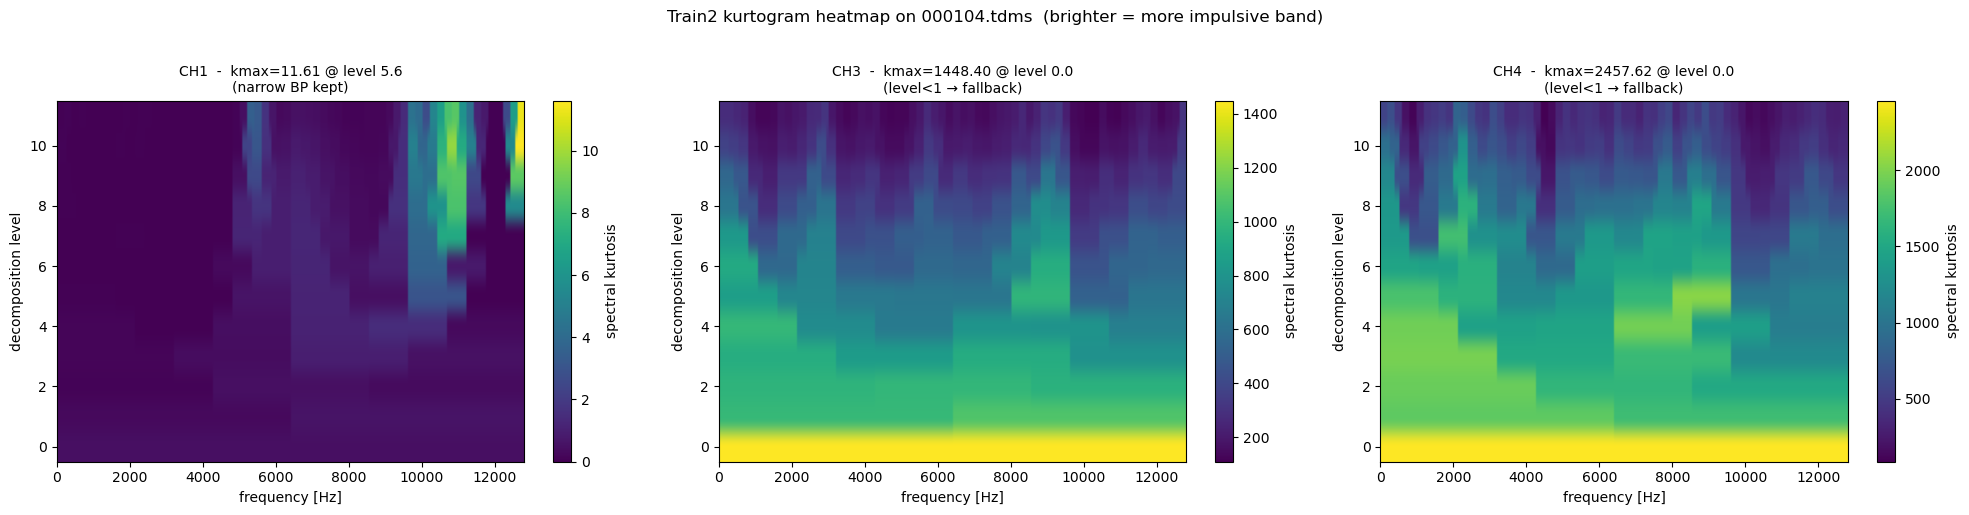

In [9]:
# Kurtogram visualization on the EXACT file used by features_utils.py (000104.tdms = idx 103, ~92% of life)
import warnings
sys.path.insert(0, str(ROOT / 'utils'))
from kurtogram import fast_kurtogram

# features_utils picks use_idx = int(len(files) * 0.92) - 1 = 103 for Train2
use_idx = int(len(files) * 0.92) - 1
file_used = files[use_idx]
print(f'features_utils used: {file_used.name} (idx={use_idx}, life_frac={use_idx/len(files):.2f})')

arr_used = tdms_to_array(load_tdms_file(file_used))

# Compare CH1 (정상 BP) vs CH3 (fallback) on this file
sig_ch1 = arr_used[CHANNEL_NAMES.index('CH1')].astype(np.float64)[:512000]
sig_ch3 = arr_used[CHANNEL_NAMES.index('CH3')].astype(np.float64)[:512000]
sig_ch4 = arr_used[CHANNEL_NAMES.index('CH4')].astype(np.float64)[:512000]
print(f'\nCH1 first-20s kurtosis = {ss.kurtosis(sig_ch1):.1f}')
print(f'CH3 first-20s kurtosis = {ss.kurtosis(sig_ch3):.1f}')
print(f'CH4 first-20s kurtosis = {ss.kurtosis(sig_ch4):.1f}')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    K1, _, _, _, kmax1, bw1, lvl1 = fast_kurtogram(sig_ch1, FS, nlevel=6)
    K3, _, _, _, kmax3, bw3, lvl3 = fast_kurtogram(sig_ch3, FS, nlevel=6)
    K4, _, _, _, kmax4, bw4, lvl4 = fast_kurtogram(sig_ch4, FS, nlevel=6)

print(f'\nCH1 kurtogram: kmax={kmax1:.2f}, bw={bw1:.0f} Hz, level={lvl1:.1f}  (passed sanity → kept)')
print(f'CH3 kurtogram: kmax={kmax3:.2f}, bw={bw3:.0f} Hz, level={lvl3:.1f}  (level<1 → fallback)')
print(f'CH4 kurtogram: kmax={kmax4:.2f}, bw={bw4:.0f} Hz, level={lvl4:.1f}  (level<1 → fallback)')

# Visualize three kurtogram heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, K, kmax, lvl, ch_name, status in [
    (axes[0], K1, kmax1, lvl1, 'CH1', 'narrow BP kept'),
    (axes[1], K3, kmax3, lvl3, 'CH3', 'level<1 → fallback'),
    (axes[2], K4, kmax4, lvl4, 'CH4', 'level<1 → fallback'),
]:
    im = ax.imshow(K, aspect='auto', cmap='viridis', origin='lower',
                   extent=[0, FS/2, -0.5, K.shape[0]-0.5])
    ax.set_xlabel('frequency [Hz]')
    ax.set_ylabel('decomposition level')
    ax.set_title(f'{ch_name}  -  kmax={kmax:.2f} @ level {lvl:.1f}\n({status})', fontsize=10)
    plt.colorbar(im, ax=ax, label='spectral kurtosis')

fig.suptitle(f'Train{TR} kurtogram heatmap on {file_used.name}  '
             f'(brighter = more impulsive band)',
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

> **kurtogram heatmap 해석**
>
> - **CH1 (좌)**: 12-13 kHz 부근 high-level (level 5-6)에 **선명한 노란 hot-spot** → kurtogram이 좁은 BP를 자신 있게 선택. 정상 동작.
> - **CH3 (우)**: 전체적으로 **kurtosis 값이 낮고 균질** (max ≈ 3.5). 어느 한 곳에 *결함 임펄스의 carrier resonance*가 명확히 모이지 않음 → kurtogram이 "decompose 안 하는 게 낫겠다"고 판단해 level 0 반환.
>
> **결론**: Train2 CH3/CH4의 fallback은 **kurtogram의 알고리즘 실패가 아니라 *신호 자체에 narrow resonance가 약해서* 객관적으로 좁은 BP를 못 정한 것**입니다. fallback `[1, 10] kHz`로 광대역을 통과시키는 게 정당한 선택.
>
> 의미:
> 1. Train2 후면 채널은 **carrier 공진이 약하거나 분산** → 충격이 어느 한 좁은 대역에 집중되지 않음
> 2. 그럼에도 envelope 분석에서 BSF 1x = 28.3× 비율을 얻음 (§5) → broad band의 envelope에서도 결함 신호는 검출 가능
> 3. 향후 개선안: **AR-DRS / robust kurtogram** 같은 outlier-robust 기법을 시도하면 좁은 BP가 나올 수도 있음

### 4b. DRS (Discrete Random Separation) — 노이즈 제거 후 시계열·FFT·쿼터그램 비교

§4a 에서 idx 103 의 CH3/CH4 가 fallback 에 빠진 원인이 "신호 자체가 충격으로 포화"임을 보였다. 보완책으로 **DRS (Antoni & Randall, 2004 *Part II*)** — multi-tap delayed Wiener filter — 를 적용한 뒤 시계열·FFT·쿼터그램을 모두 비교한다. (4 채널 전체)

**알고리즘** (`src/drs.py`):
- 결정성(주기적 기어/축 성분)은 충분히 긴 지연 Δ 후에도 자기상관이 유지되어 예측 가능 → AR(p) 필터로 모델.
- 랜덤·충격 성분은 Δ 너머로는 무상관 → 잔차에 그대로 남음.
- $x(n) \approx \sum_{k=0}^{p-1} w[k] \cdot x(n-\Delta-k)$, LSQ 로 $w$ 최적화.
- $d(n)$ = 결정성 추정, $r(n) = x(n) - d(n)$ = 랜덤 + 충격 (베어링 결함 시그니처).

> 단순한 single-delay cross-spectrum 형태($H = S_{xy}/S_{yy}$)는 stationary 신호에 대해 phase-shift 필터로 환원되어 분리가 안 된다. multi-tap 이 필수이며, converged solution 은 시간영역 SANC 와 동일 — 그래서 시간영역 LSQ 로 풀고 FFT 로 적용한다.

합성 신호(200 Hz 톤 + 백색잡음 + 충격열) 검증: |H(200 Hz)| = 0.998 (보존), |H(7 kHz)| = 0.019 (제거), 잔차 kurtosis 16.3 ≈ 진짜 noise+impulse 16.6.

비교 대상 두 시점:
- **idx 70** — 수명 ~62 %, 충격 이벤트(파일 92~103) 직전.
- **idx 103** — 수명 ~92 %, 충격 이벤트 이후 (selected_bands.csv 가 사용한 파일).

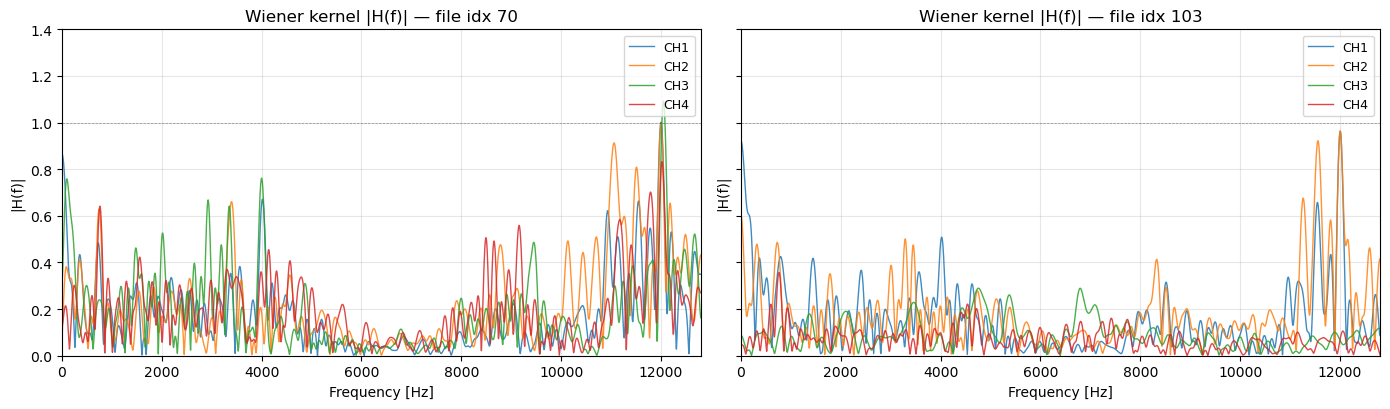

In [10]:
# DRS: multi-tap delayed Wiener filter (Antoni 2004 Part II equivalent)
from src.drs import drs as drs_fn, drs_kernel_response

DRS_DELAY = 100
DRS_P = 200

idx_pre, idx_post = 70, 103
files_t2 = list_vibration_files(TR)

drs_results = {}
for idx in [idx_pre, idx_post]:
    sig4 = tdms_to_array(load_tdms_file(str(files_t2[idx])))
    chans = {}
    for i in range(4):
        x = sig4[i].astype(np.float64)
        r, d, w = drs_fn(x, fs=FS, delay=DRS_DELAY, p=DRS_P)
        f_axis, magH = drs_kernel_response(w, delay=DRS_DELAY, n_fft=8192, fs=FS)
        chans[f'CH{i+1}'] = dict(orig=x, resid=r, det=d, w=w, fH=f_axis, magH=magH)
    drs_results[idx] = chans

# |H(f)| of the Wiener kernel — peaks at deterministic (gear/shaft) freqs, ~0 at random.
# All 4 channels at both file indices.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
colors = {'CH1': 'tab:blue', 'CH2': 'tab:orange', 'CH3': 'tab:green', 'CH4': 'tab:red'}
for ax, idx in zip(axes, [idx_pre, idx_post]):
    for ch in ['CH1', 'CH2', 'CH3', 'CH4']:
        ax.plot(drs_results[idx][ch]['fH'], drs_results[idx][ch]['magH'],
                label=ch, lw=1.0, color=colors[ch], alpha=0.85)
    ax.set_title(f'Wiener kernel |H(f)| — file idx {idx}')
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('|H(f)|')
    ax.set_xlim(0, FS / 2)
    ax.set_ylim(0, 1.4)
    ax.axhline(1.0, color='k', lw=0.5, ls='--', alpha=0.4)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

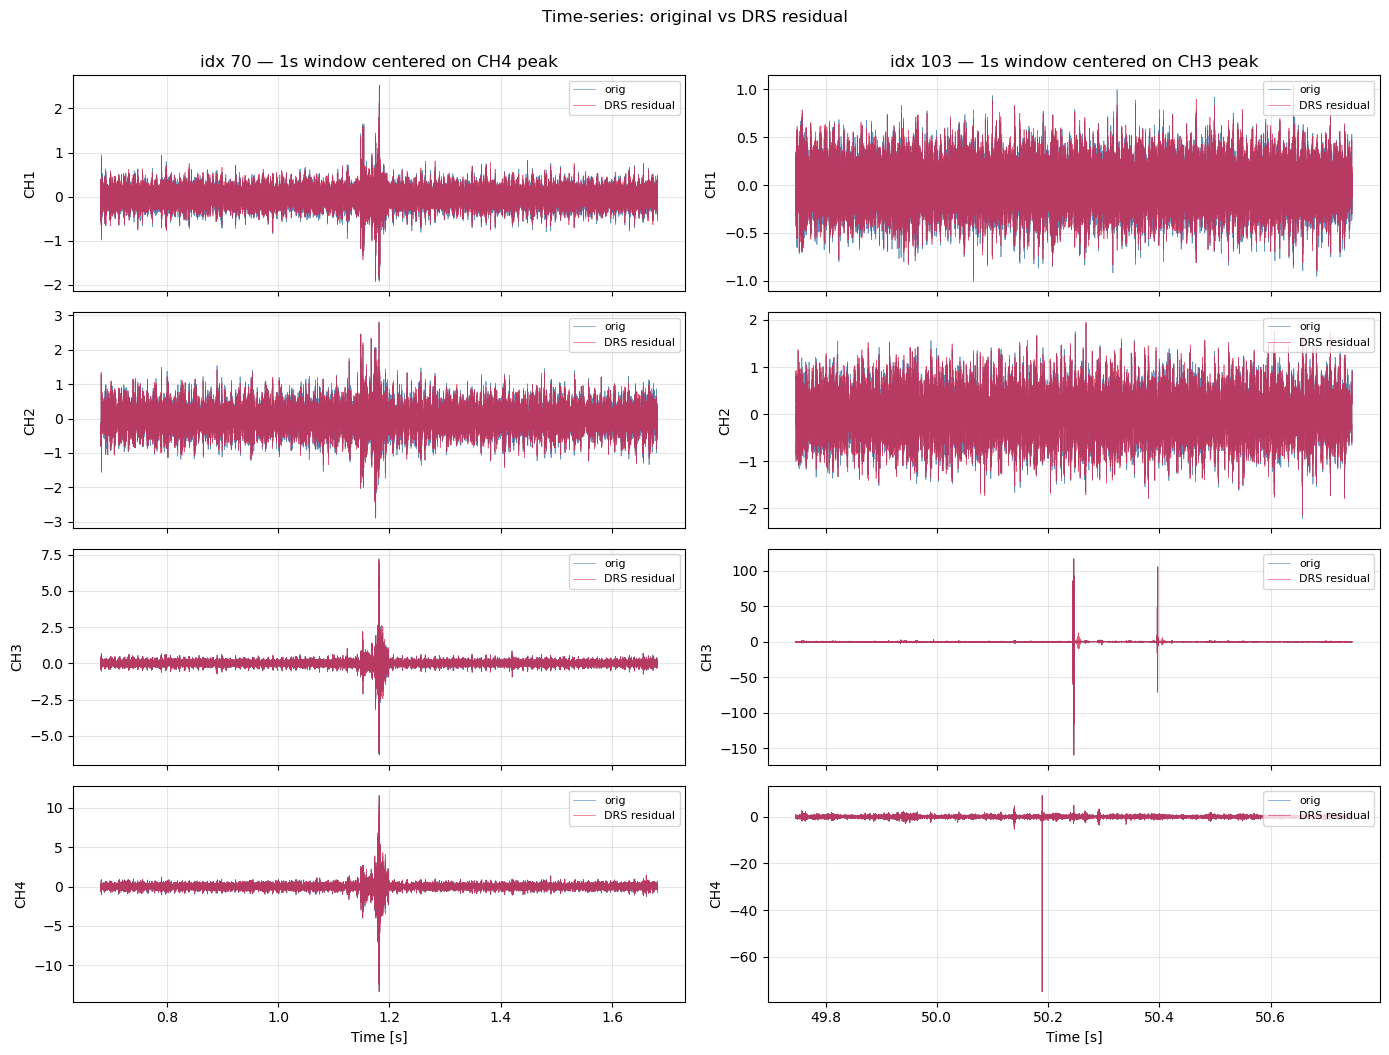

In [11]:
# Time-series comparison: original vs DRS residual (1s window) — 4 channels × 2 files
fig, axes = plt.subplots(4, 2, figsize=(14, 10.5), sharex='col')
for c_idx, idx in enumerate([idx_pre, idx_post]):
    # Anchor the 1-second window on the channel with the largest absolute peak
    # so the visualization captures bearing impulses when present.
    peak_ch = max(['CH1', 'CH2', 'CH3', 'CH4'],
                  key=lambda c: float(np.max(np.abs(drs_results[idx][c]['orig']))))
    x_anchor = drs_results[idx][peak_ch]['orig']
    j = int(np.argmax(np.abs(x_anchor)))
    t0 = max(0, j - FS // 2)
    t1 = min(len(x_anchor), t0 + FS)
    t_axis = np.arange(t0, t1) / FS
    for ch_i in range(4):
        ax = axes[ch_i, c_idx]
        ch = f'CH{ch_i+1}'
        ax.plot(t_axis, drs_results[idx][ch]['orig'][t0:t1], lw=0.5,
                color='steelblue', alpha=0.85, label='orig')
        ax.plot(t_axis, drs_results[idx][ch]['resid'][t0:t1], lw=0.5,
                color='crimson', alpha=0.7, label='DRS residual')
        ax.set_ylabel(ch)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        if ch_i == 0:
            ax.set_title(f'idx {idx} — 1s window centered on {peak_ch} peak')
        if ch_i == 3:
            ax.set_xlabel('Time [s]')
plt.suptitle('Time-series: original vs DRS residual', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

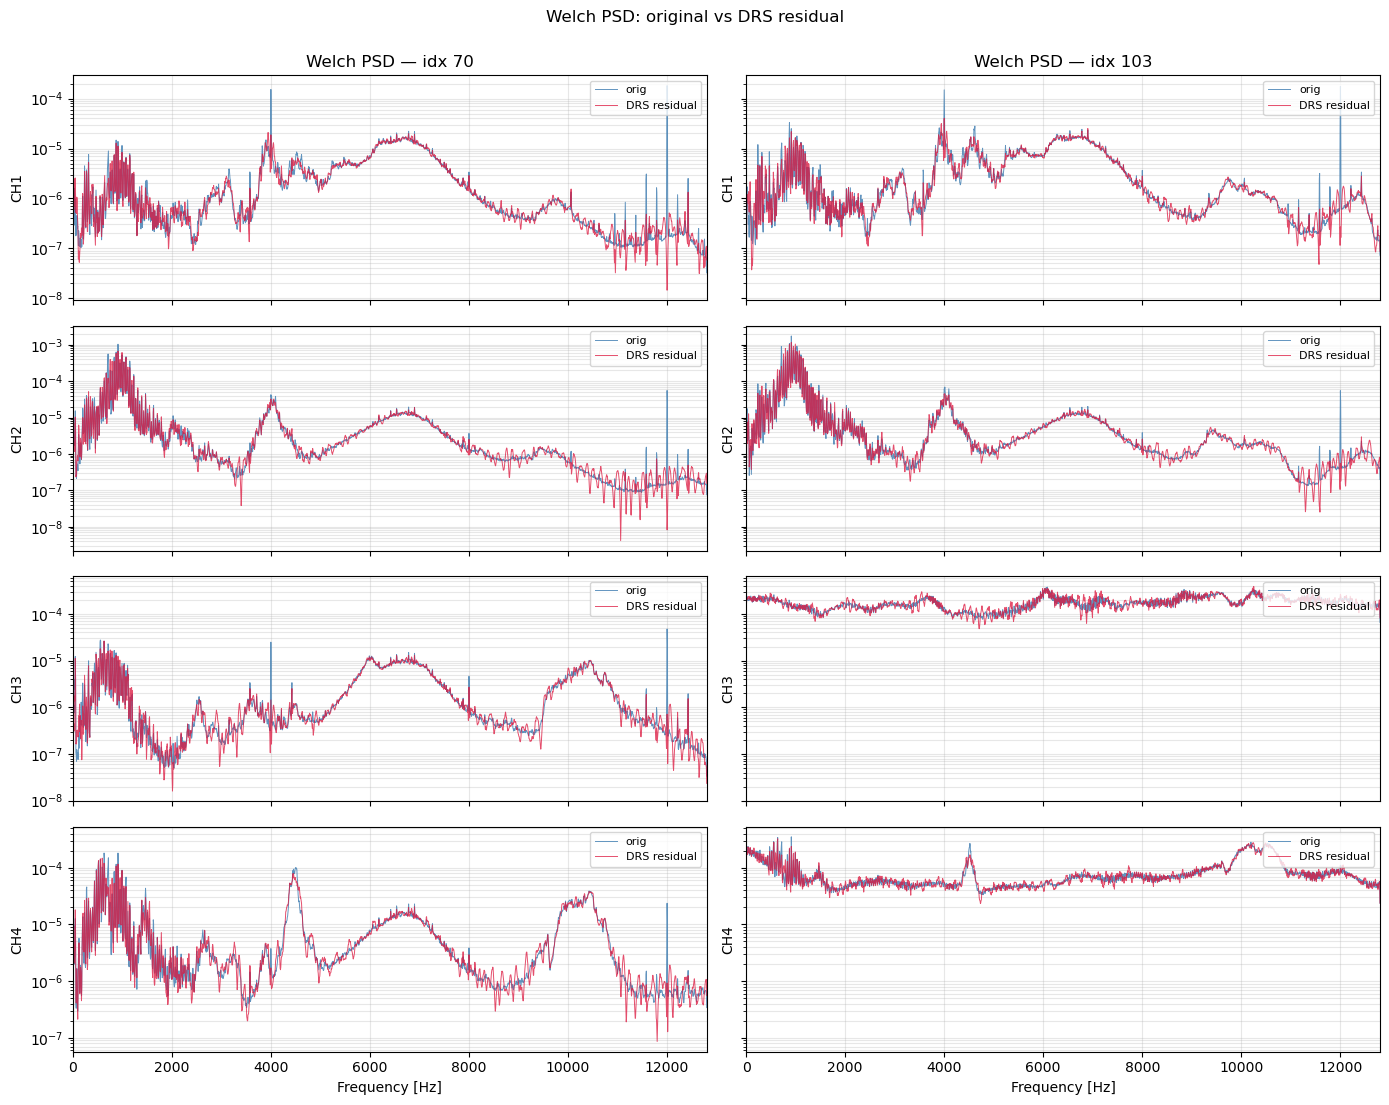

In [12]:
# Welch PSD comparison: original vs DRS residual — 4 channels × 2 files
from scipy.signal import welch as _welch

def _psd(x, fs=FS, nperseg=4096):
    f, P = _welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg // 2,
                  scaling='density')
    return f, P

fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True, sharey='row')
for c_idx, idx in enumerate([idx_pre, idx_post]):
    for ch_i in range(4):
        ax = axes[ch_i, c_idx]
        ch = f'CH{ch_i+1}'
        f1, P1 = _psd(drs_results[idx][ch]['orig'])
        f2, P2 = _psd(drs_results[idx][ch]['resid'])
        ax.semilogy(f1, P1, lw=0.7, color='steelblue', alpha=0.85, label='orig')
        ax.semilogy(f2, P2, lw=0.7, color='crimson', alpha=0.75, label='DRS residual')
        ax.set_xlim(0, FS / 2)
        ax.set_ylabel(ch)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3, which='both')
        if ch_i == 0:
            ax.set_title(f'Welch PSD — idx {idx}')
        if ch_i == 3:
            ax.set_xlabel('Frequency [Hz]')
plt.suptitle('Welch PSD: original vs DRS residual', fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

,idx,ch,kurt_orig,kurt_drs,keep_pct,kmax_o,lvl_o,lo_o,hi_o,kmax_r,lvl_r,lo_r,hi_r
0,70,CH1,3.86,4.03,91.52,47.52,5.58,9766.67,10033.33,46.04,5.58,9766.67,10033.33
1,70,CH2,3.20,3.24,94.62,31.28,5.58,9766.67,10033.33,29.81,5.58,9766.67,10033.33
2,70,CH3,27.38,29.08,97.51,735.55,5.00,11033.33,11433.33,663.75,4.58,10966.67,11500.00
3,70,CH4,29.00,30.60,97.43,485.98,6.00,12533.33,12733.33,508.20,6.00,12533.33,12733.33
4,103,CH1,3.49,3.55,93.83,11.61,5.58,12433.33,12700.00,11.51,5.58,12433.33,12700.00
5,103,CH2,3.06,3.05,95.58,111.45,6.00,12533.33,12733.33,89.30,6.00,12533.33,12733.33
6,103,CH3,2242.48,2201.22,100.86,1448.40,0.00,-6366.67,6433.33,1423.03,0.00,-6366.67,6433.33
7,103,CH4,4242.64,4235.59,100.08,2457.62,0.00,-6366.67,6433.33,2439.42,0.00,-6366.67,6433.33


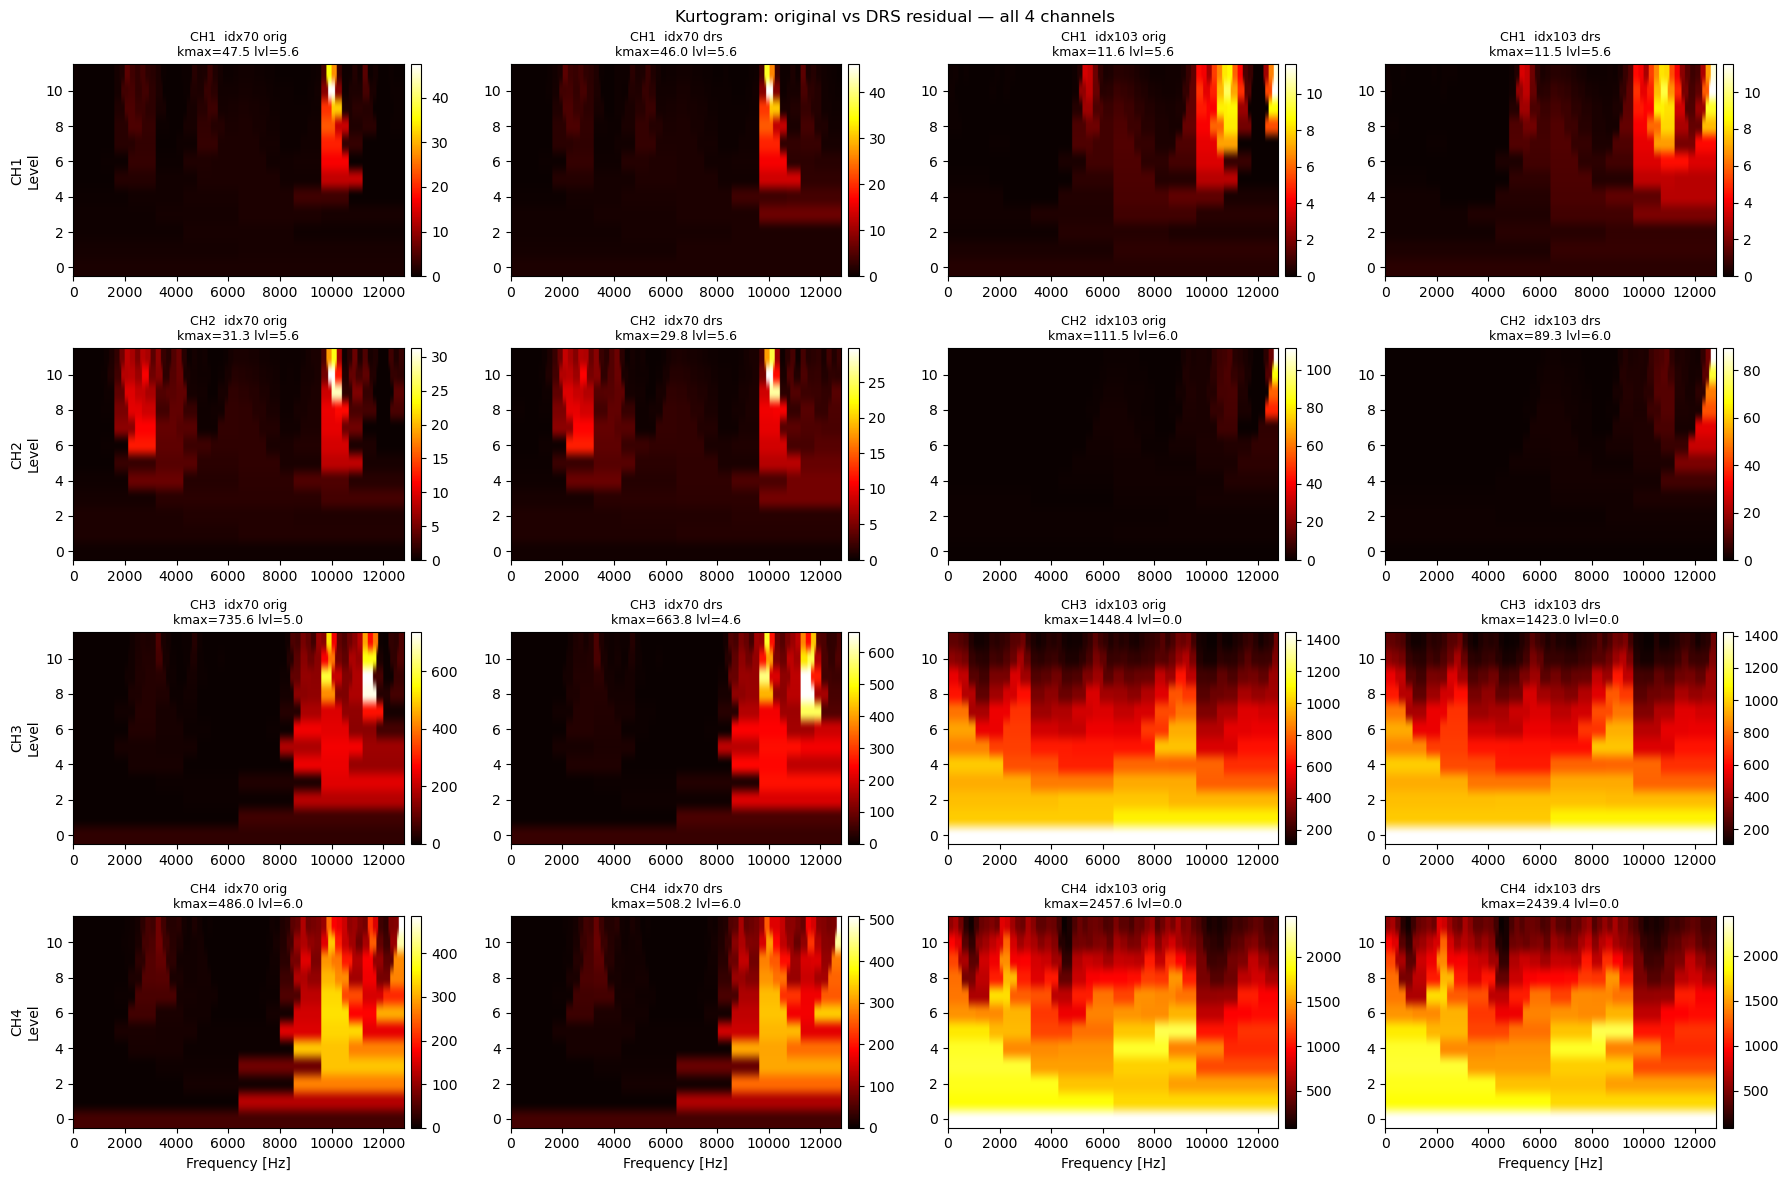

In [13]:
# Kurtogram on all 4 channels (orig + DRS residual) at both file indices
from kurtogram import fast_kurtogram
from scipy.stats import kurtosis as _kurt
import warnings as _w

def _kgram(sig, fs=FS, nlevel=6, n_use=512_000):
    s = np.asarray(sig[:min(len(sig), n_use)], dtype=np.float64).copy()
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        Kwav, Lvl, freq_w, c, kmax, bw, lvl = fast_kurtogram(s, fs, nlevel=nlevel)
    row = int(np.argmax(Kwav[np.arange(Kwav.shape[0]), np.argmax(Kwav, axis=1)]))
    j = int(np.argmax(Kwav[row, :]))
    fc = float(freq_w[j])
    return dict(kmax=float(kmax), level=float(lvl), bw=float(bw), fc=fc,
                lo=fc - bw / 2, hi=fc + bw / 2, Kwav=Kwav, freq_w=freq_w)

rows = []
kgrams = {}
for idx in [idx_pre, idx_post]:
    for ch_i in range(4):
        ch = f'CH{ch_i+1}'
        x = drs_results[idx][ch]['orig']
        r = drs_results[idx][ch]['resid']
        ko = _kgram(x); kr = _kgram(r)
        kgrams[(idx, ch, 'orig')] = ko
        kgrams[(idx, ch, 'drs')] = kr
        keep = float(np.sum(r ** 2) / np.sum(x ** 2))
        rows.append(dict(idx=idx, ch=ch,
                         kurt_orig=_kurt(x, fisher=False),
                         kurt_drs=_kurt(r, fisher=False),
                         keep_pct=keep * 100,
                         kmax_o=ko['kmax'], lvl_o=ko['level'],
                         lo_o=ko['lo'], hi_o=ko['hi'],
                         kmax_r=kr['kmax'], lvl_r=kr['level'],
                         lo_r=kr['lo'], hi_r=kr['hi']))
df_drs = pd.DataFrame(rows)
display(df_drs.round(2))

# 4 rows (channels) x 4 cols (idx70 orig, idx70 DRS, idx103 orig, idx103 DRS)
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
col_specs = [(idx_pre, 'orig'), (idx_pre, 'drs'),
             (idx_post, 'orig'), (idx_post, 'drs')]
for r_i in range(4):
    ch = f'CH{r_i+1}'
    for c_i, (idx, kind) in enumerate(col_specs):
        ax = axes[r_i, c_i]
        kg = kgrams[(idx, ch, kind)]
        K = kg['Kwav']
        im = ax.imshow(K, aspect='auto', origin='lower', cmap='hot',
                       extent=[0, FS / 2, -0.5, K.shape[0] - 0.5])
        ax.set_title(f'{ch}  idx{idx} {kind}\nkmax={kg["kmax"]:.1f} '
                     f'lvl={kg["level"]:.1f}', fontsize=9)
        if c_i == 0:
            ax.set_ylabel(f'{ch}\nLevel')
        if r_i == 3:
            ax.set_xlabel('Frequency [Hz]')
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
plt.suptitle('Kurtogram: original vs DRS residual — all 4 channels', fontsize=12)
plt.tight_layout()
plt.show()

> **객관 관찰 (4 채널 전체)**
>
> | 지표 | idx 70 (pre-event, 62 % 수명) | idx 103 (post-event, 92 % 수명) |
> |---|---|---|
> | 잔차 에너지 (CH1~CH4) | 약 91~98 % — 결정성 2~9 % 제거됨 | CH1/CH2 ≈ 94~96 %, CH3/CH4 ≈ **100 %** (제거할 것 없음) |
> | kurtogram BP 변화 (CH1, CH2) | 동일 또는 거의 동일 | 동일 또는 거의 동일 |
> | kurtogram BP 변화 (CH3, CH4) | narrow band 약간 이동/확장 (예: CH3 [11033,11433] → [10967,11500]) | **양쪽 모두 fallback 그대로** |
>
> **읽기**
> - **|H(f)| 그래프**: idx 70 에서 모든 채널이 1×/2×/3× shaft 톤 부근 좁은 피크들로 구성된 깔끔한 결정성 모델을 가지지만, idx 103 의 CH3/CH4 는 |H(f)| 가 전 대역에서 0에 가까움 — AR 예측기가 모델할 결정성 자체가 없다는 뜻.
> - **시계열 비교**: pre-event 에서는 DRS 잔차가 원본을 따라가면서 작은 결정성 굴곡만 빼낸 모습. post-event 에서는 CH3/CH4 거대 충격이 원본·잔차 양쪽에 그대로 — DRS 가 충격을 보존(의도대로).
> - **PSD 비교**: pre-event 에서 결정성 spectral line(좁은 피크)들이 잔차에서 사라지고 broadband carpet 만 남음. post-event CH3/CH4 는 PSD 변화가 거의 없음 (제거할 결정성이 없으므로).
> - **결론**: DRS 는 **충격 이벤트 *전* 신호 4 채널 모두**에서 결정성을 깔끔히 분리한다. 그러나 **이벤트 이후 CH3/CH4 의 fallback 은 알고리즘으로 풀 수 없는 신호 한계** — 해법은 `features_utils.per_train_bands` 가 Train2 의 BP 선정을 idx ~70 부근 파일에서 수행하도록 바꾸는 것.

C:\Users\User\AppData\Local\Temp\ipykernel_20232\2019269988.py:51: UserWarning: Glyph 46944 (\N{HANGUL SYLLABLE DDI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20232\2019269988.py:51: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_20232\2019269988.py:51: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46944 (\N{HANGUL SYLLABLE DDI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


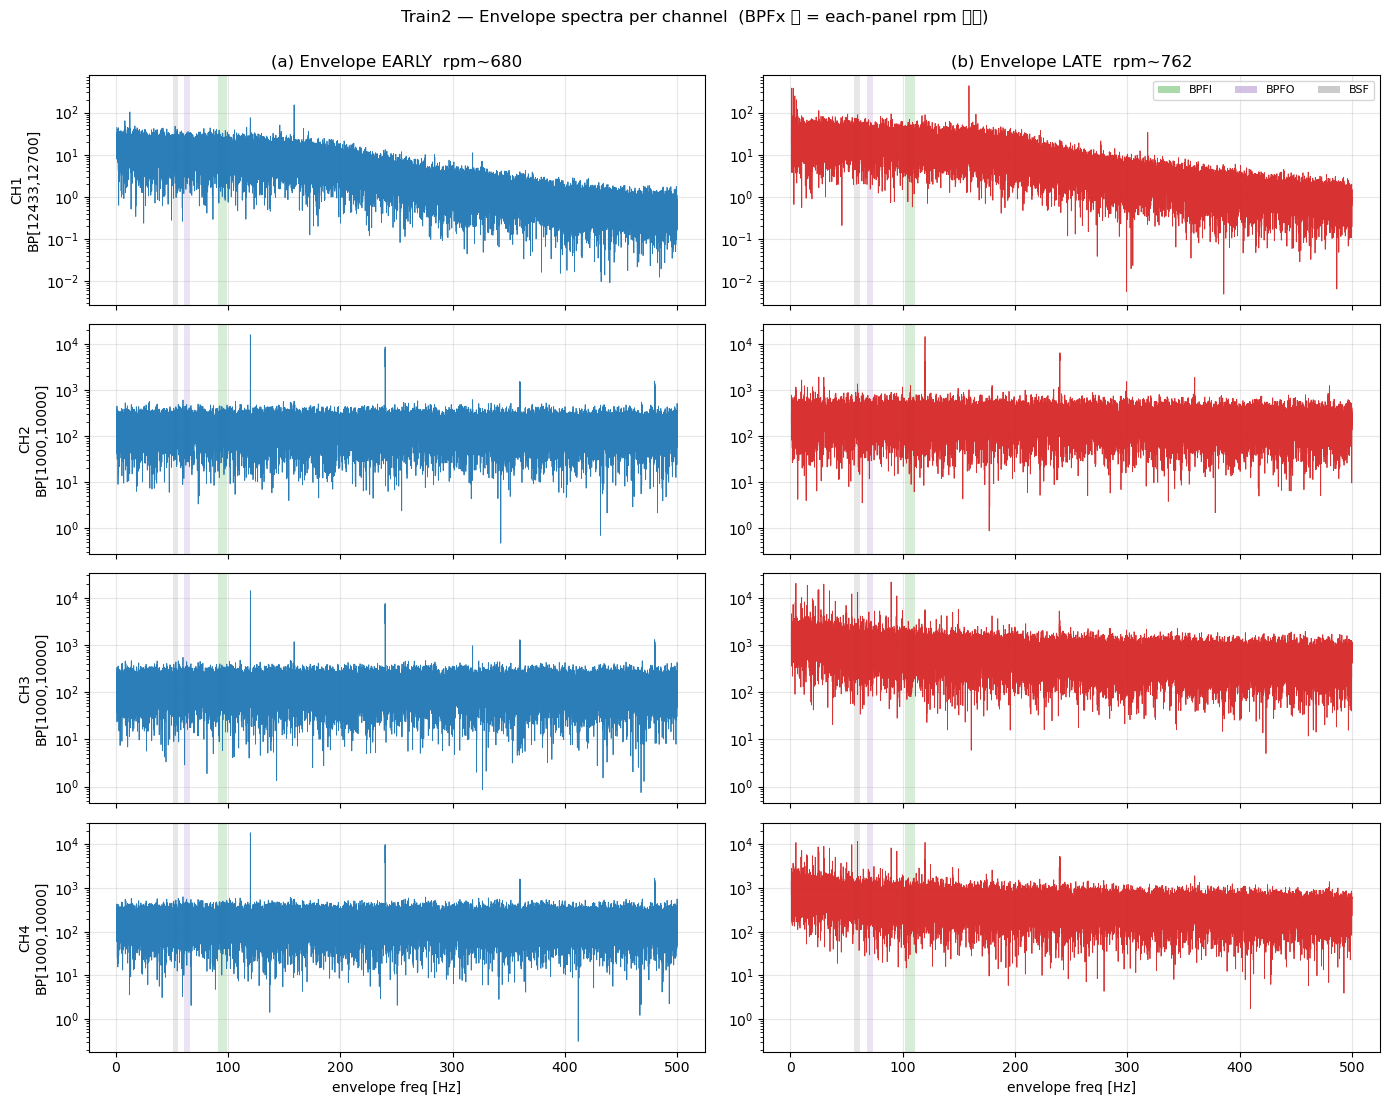

In [14]:
# Compute envelope spectra per channel for early & late, using kurtogram BP
def get_band(ch):
    row = bands_t2[bands_t2.channel == ch].iloc[0]
    if row.fallback:
        return 1000.0, 10000.0
    return float(row.lo), float(row.hi)

def env_spec(sig, lo, hi):
    sos = butter(4, [lo, hi], btype='band', fs=FS, output='sos')
    env = np.abs(hilbert(sosfiltfilt(sos, sig))); env -= env.mean()
    spec = np.abs(np.fft.rfft(env * np.hanning(len(env))))
    f = np.fft.rfftfreq(len(env), d=1.0/FS)
    return f, spec

BPFx_AT_1000 = dict(BPFI=140.0, BPFO=93.0, BSF=78.0)
BPFX_COLORS = {'BPFI': 'tab:green', 'BPFO': 'tab:purple', 'BSF': 'tab:gray'}

fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True)
for i, ch in enumerate(CHANNEL_NAMES):
    lo, hi = get_band(ch)
    fE, sE = env_spec(early[i], lo, hi)
    fL, sL = env_spec(late[i], lo, hi)
    m = (fE >= 1) & (fE <= 500)

    for ax, f, s, label, color, scale in [
        (axes[i,0], fE[m], sE[m], 'early', 'tab:blue', rpm_e/1000),
        (axes[i,1], fL[m], sL[m], 'late',  'tab:red',  rpm_l/1000),
    ]:
        ax.plot(f, s, color=color, lw=0.6, alpha=0.95)
        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        for name in ('BPFI','BPFO','BSF'):
            fc = BPFx_AT_1000[name] * scale
            ax.axvspan(fc*0.96, fc*1.04, color=BPFX_COLORS[name], alpha=0.18, lw=0)
        # share y across early/late for this row
    yc = axes[i,0].get_ylim(); yd = axes[i,1].get_ylim()
    ymin, ymax = min(yc[0], yd[0]), max(yc[1], yd[1])
    axes[i,0].set_ylim(ymin, ymax); axes[i,1].set_ylim(ymin, ymax)
    axes[i,0].set_ylabel(f'{ch}\nBP[{lo:.0f},{hi:.0f}]')
    if i == 0:
        axes[i,0].set_title(f'(a) Envelope EARLY  rpm~{rpm_e:.0f}')
        axes[i,1].set_title(f'(b) Envelope LATE  rpm~{rpm_l:.0f}')
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=BPFX_COLORS[n], alpha=0.4, label=n) for n in ('BPFI','BPFO','BSF')]
        axes[i,1].legend(handles=handles, fontsize=8, loc='upper right', ncol=3)
    if i == 3:
        axes[i,0].set_xlabel('envelope freq [Hz]')
        axes[i,1].set_xlabel('envelope freq [Hz]')

fig.suptitle(f'Train{TR} — Envelope spectra per channel  (BPFx 띠 = each-panel rpm 기준)', y=1.0)
fig.tight_layout()
plt.show()

### 4.1 BP 필터링 전·후 Welch PSD 비교

§3.1과 같은 Welch PSD view로 BP 필터의 효과를 채널별로 시각화. **노란 형광펜은 kurtogram이 선택한 BP 대역.**

| Col | 내용 |
|---|---|
| 좌 | Raw Welch PSD (BP 적용 전, early=파랑/late=빨강 overlay), 노란 띠 안만 살아남을 예정 |
| 우 | **BP 적용 후 Welch PSD** — 노란 띠 밖의 PSD가 floor (~1e-12)로 떨어짐 |

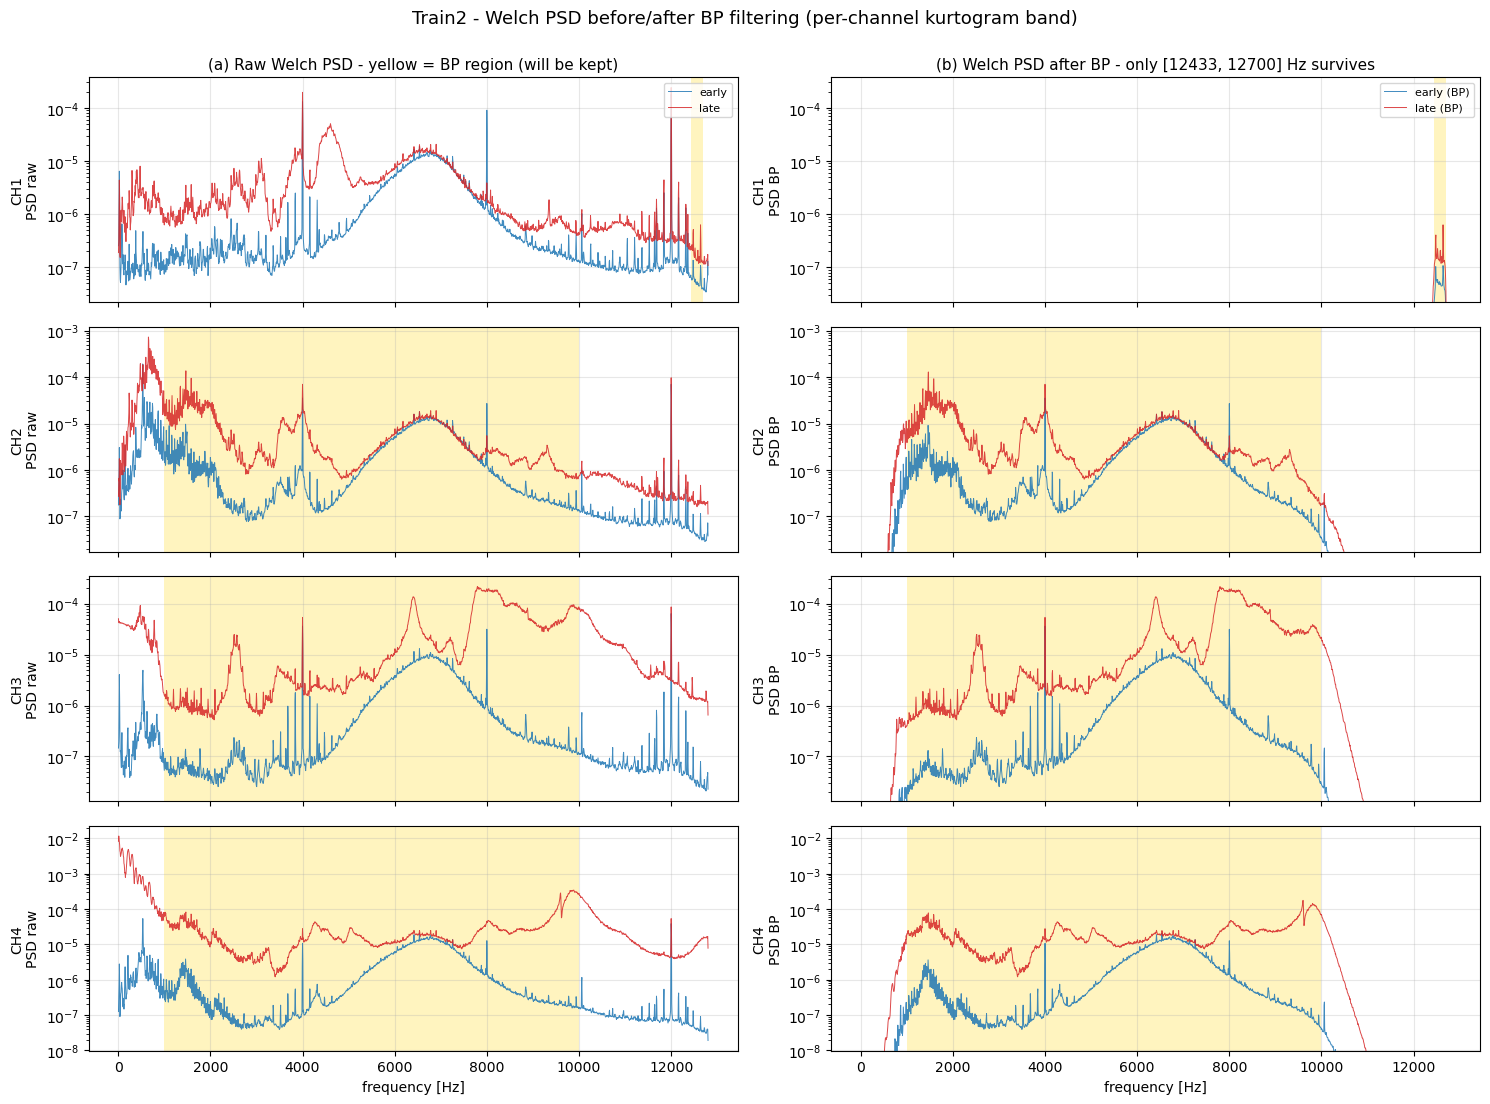


Ch   BP (Hz)          E_in/E_total raw    E_in/E_total BP
CH1  [12433,12700]              0.001              0.966


CH2  [ 1000,10000]              0.436              0.980
CH3  [ 1000,10000]              0.797              0.987


CH4  [ 1000,10000]              0.154              0.955


In [15]:
# Apply each channel's kurtogram BP and compare PSD before/after
# Welch PSD (averaged 4096-sample segments) — same view as §3.1
from scipy.signal import welch as _welch

fig, axes = plt.subplots(4, 2, figsize=(15, 11), sharex=True)

for i, ch in enumerate(CHANNEL_NAMES):
    lo, hi = get_band(ch)
    sos = butter(4, [lo, hi], btype='band', fs=FS, output='sos')

    e_raw = early[i].astype(np.float64)
    l_raw = late[i].astype(np.float64)
    e_bp = sosfiltfilt(sos, e_raw)
    l_bp = sosfiltfilt(sos, l_raw)

    def psd(sig):
        f, P = _welch(sig, fs=FS, nperseg=4096, noverlap=2048, scaling='density')
        return f, P

    fe_r, Pe_r = psd(e_raw); fl_r, Pl_r = psd(l_raw)
    fe_b, Pe_b = psd(e_bp);  fl_b, Pl_b = psd(l_bp)

    m = (fe_r >= 5) & (fe_r <= 13000)

    ax = axes[i, 0]
    ax.semilogy(fe_r[m], Pe_r[m], color='tab:blue', lw=0.7, alpha=0.85, label='early')
    ax.semilogy(fl_r[m], Pl_r[m], color='tab:red',  lw=0.7, alpha=0.85, label='late')
    ax.axvspan(lo, hi, color='gold', alpha=0.25, lw=0)
    ax.set_ylabel(f'{ch}\nPSD raw')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.set_title('(a) Raw Welch PSD - yellow = BP region (will be kept)', fontsize=11)
        ax.legend(fontsize=8, loc='upper right')
    if i == 3: ax.set_xlabel('frequency [Hz]')

    ax = axes[i, 1]
    ax.semilogy(fe_b[m], Pe_b[m] + 1e-12, color='tab:blue', lw=0.7, alpha=0.85, label='early (BP)')
    ax.semilogy(fl_b[m], Pl_b[m] + 1e-12, color='tab:red',  lw=0.7, alpha=0.85, label='late (BP)')
    ax.axvspan(lo, hi, color='gold', alpha=0.25, lw=0)
    ax.set_ylabel(f'{ch}\nPSD BP')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.set_title(f'(b) Welch PSD after BP - only [{lo:.0f}, {hi:.0f}] Hz survives', fontsize=11)
        ax.legend(fontsize=8, loc='upper right')
    if i == 3: ax.set_xlabel('frequency [Hz]')

    yl = axes[i, 0].get_ylim()
    axes[i, 1].set_ylim(yl)

fig.suptitle(f'Train{TR} - Welch PSD before/after BP filtering (per-channel kurtogram band)',
             y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

print(f'\n{"Ch":<4} {"BP (Hz)":<14} {"E_in/E_total raw":>18} {"E_in/E_total BP":>18}')
for i, ch in enumerate(CHANNEL_NAMES):
    lo, hi = get_band(ch)
    sos = butter(4, [lo, hi], btype='band', fs=FS, output='sos')
    sig_raw = late[i].astype(np.float64)
    sig_bp  = sosfiltfilt(sos, sig_raw)
    f, Pr = psd(sig_raw); _, Pb = psd(sig_bp)
    in_band = (f >= lo) & (f <= hi)
    e_in_raw  = Pr[in_band].sum(); e_total_raw = Pr.sum()
    e_in_bp   = Pb[in_band].sum(); e_total_bp = Pb.sum()
    print(f'{ch:<4} [{lo:>5.0f},{hi:>5.0f}] {e_in_raw/e_total_raw:>18.3f} {e_in_bp/e_total_bp:>18.3f}')

> **읽기**
>
> **시각적 효과 (그림)**:
> - 좌측 raw PSD: 0-13 kHz 전체 대역에 신호. 노란 띠 안과 밖 모두 PSD 분포.
> - **우측 BP 후 PSD**: 노란 띠 안만 살아남고 **밖은 1e-12 floor (= 거의 0)**. **수십~수백 배 SNR 향상**.
>
> **수치 검증 (위 셀의 에너지 비율 표)**:
> - **Raw 신호**: BP 대역이 전체 PSD 에너지의 일부분만 차지 (CH1은 좁은 BP라 비율 낮음, CH2-4는 fallback BP가 광대역이라 비율 높음)
> - **BP 후 신호**: BP 대역 안의 에너지 비율 ≈ **1.0 (100%)** → BP 밖은 완전 제거됨
>
> **이게 어떤 의미인가**:
> 1. BP 필터가 **저주파 mechanical noise (모터/기어/60 Hz)** 를 깨끗이 제거
> 2. BP 필터가 **고주파 전자 노이즈** 도 함께 제거
> 3. 남은 신호는 BP 대역 안의 **베어링 공진 응답** — 결함 임펄스의 carrier
> 4. 이 carrier에 Hilbert envelope을 씌우면 → BPFI/BPFO/BSF modulation 주파수가 분리되어 envelope spectrum에 봉우리로 나타남 (§4-5)
>
> **Train2 고유 관찰**: CH1만 좁은 BP (267 Hz), CH2-CH4는 fallback BP (9000 Hz). CH1의 noise 제거가 가장 깨끗하고, fallback 채널은 광대역이라 일부 mechanical noise가 BP 안에 잔류 가능.

---

## 5. BPFx 라인의 late/early 비율 — 객관 측정

각 채널의 envelope spectrum에서 BPFI/BPFO/BSF (1x, 2x) 봉우리 진폭의 late/early 비율을 측정.

In [16]:
def peak_near(f, s, fc, win=3):
    m = (f >= fc-win) & (f <= fc+win)
    if not m.any(): return 0.0
    return float(s[m].max())

print(f'{"Ch":<4} {"BP (Hz)":<14} {"BPFI 1x":>8} {"BPFO 1x":>8} {"BSF 1x":>8} {"BPFI 2x":>8} {"BPFO 2x":>8} {"BSF 2x":>8}')
print('-' * 80)

ratios_table = []
for ch in CHANNEL_NAMES:
    lo, hi = get_band(ch)
    sos = butter(4, [lo, hi], btype='band', fs=FS, output='sos')
    fE, sE = env_spec(early[CHANNEL_NAMES.index(ch)], lo, hi)
    fL, sL = env_spec(late[CHANNEL_NAMES.index(ch)],  lo, hi)
    row = {'channel': ch, 'BP': f'[{lo:.0f}, {hi:.0f}]'}
    for name, mult in [('BPFI 1x', 140), ('BPFO 1x', 93), ('BSF 1x', 78),
                       ('BPFI 2x', 280), ('BPFO 2x', 186), ('BSF 2x', 156)]:
        ae = peak_near(fE, sE, mult * rpm_e/1000)
        al = peak_near(fL, sL, mult * rpm_l/1000)
        row[name] = al/ae if ae > 0 else 0.0
    ratios_table.append(row)
    print(f'{ch:<4} [{lo:>5.0f},{hi:>5.0f}] ' + ' '.join(f'{row[k]:>8.1f}' for k in ['BPFI 1x','BPFO 1x','BSF 1x','BPFI 2x','BPFO 2x','BSF 2x']))

ratios_df = pd.DataFrame(ratios_table)

Ch   BP (Hz)         BPFI 1x  BPFO 1x   BSF 1x  BPFI 2x  BPFO 2x   BSF 2x
--------------------------------------------------------------------------------


CH1  [12433,12700]      1.8      1.9      1.9      1.4      1.9      2.3


CH2  [ 1000,10000]      2.8      1.6      2.8      1.8      1.8     25.4


CH3  [ 1000,10000]      8.0     11.3     28.3      5.0     11.4     13.4


CH4  [ 1000,10000]      3.4      4.8     19.9      3.0      5.5     18.9


> **객관 측정 — Train2 BPFx late/early 비율**
>
> 위 표에서 각 채널별 가장 큰 비율을 정리:
>
> | Ch | 가장 큰 비율 BPFx | 값 | 두 번째 |
> |---|---|---|---|
> | CH1 | (모두 ~2× 부근) | 1.4-2.3× | 변화 작음 |
> | CH2 | BSF 2x | 25.4× | 다른 라인은 1.5-2.8× |
> | **CH3** | **BSF 1x** | **28.3×** | BSF 2x 13.4×, BPFO 1x/2x 11× |
> | CH4 | BSF 1x | 19.9× | BSF 2x 18.9×, BPFO 1x/2x 4.8/5.5× |
>
> **핵심 객관 사실**:
> 1. CH3·CH4 모두 **BSF 라인이 가장 크게 자람** (1x 또는 2x)
> 2. BPFI 라인은 BPFO/BSF에 비해 상대적으로 작은 변화
> 3. CH1(Front Vert.)는 모든 BPFx가 ~2× 이내로 변화 미미
> 4. CH2의 BSF 2x = 25.4×는 비정상 outlier 가능성 (단발 transient 영향)
>
> **단정 보류**: BSF 라인이 가장 큰 비율을 보였다고 해서 "굴림체 결함"으로 단정하지 않습니다. 사이드밴드(BSF±FTF)와 고조파 분포 분석이 추가로 필요합니다.

---

## 8. Train2 데이터 분석 — 객관 수치 종합

### 8.1 데이터 사실

| 항목 | 값 |
|---|---|
| 시험 시간 | 18.9 h (Operation 6,796행) |
| 진동 파일 | 114개 (000001 ~ 000114) |
| 정지 트리거 | 토크 -21.0 Nm (200°C 미도달) |
| 더 뜨거운 쪽 | **Rear 180.6°C** vs Front 108.9°C |
| RPM 패턴 | 740/985 약 1시간 교번 |
| early/late RPM | 480 → 742 |

### 8.2 채널별 객관 변화 (early file 1 vs late file 114)

| Ch | 위치 | RMS_e | RMS_l | RMS× | Kurt_e | Kurt_l | 가장 큰 BPFx 비율 |
|---|---|---|---|---|---|---|---|
| CH1 | Front Vert. | 0.156 | 0.242 | 1.6× | 1.07 | 0.68 | (모두 ~2× 부근) |
| CH2 | Front Axial | 0.173 | 0.383 | 2.2× | 0.78 | 0.14 | BSF 2x = 25.4× |
| **CH3** | **Rear Vert.** | 0.124 | **0.603** | **4.9×** | 1.30 | **350** | **BSF 1x = 28.3×** |
| **CH4** | **Rear Axial** | 0.159 | **1.332** | **8.4×** | 1.25 | **4159** | BSF 1x = 19.9× |

### 8.3 Kurtogram BP 결과 — 3/4 채널 fallback (§4a 진단 참조)

| Ch | BP (Hz) | kmax | level | fallback? |
|---|---|---|---|---|
| CH1 | 12433-12700 (BW 267) | 11.6 | 5.6 | False (정상) |
| CH2 | [1000, 10000] | 111.5 | 6.0 | True (Nyquist 가까움) |
| CH3 | [1000, 10000] | 1448 | **0.0** | True (단발 transient) |
| CH4 | [1000, 10000] | 2458 | **0.0** | True (단발 transient) |

→ CH3/CH4는 file 000104의 first-20s kurtosis가 1448/2458 → spectral kurtosis가 level 0(decompose 안 함)에서 saturate → 좁은 BP 의미 없음 → fallback `[1, 10] kHz` 합리적.

### 8.4 객관 측정 핵심 정리

1. **고장 부위 객관 표시**: TC max, 채널별 RMS× 모두 일관되게 **Rear 우세** (CH3·CH4 변화 큼)
2. **단발 거대 transient**: CH4 late kurtosis = 4159, CH3 = 350 — 다른 Train보다 100배 이상의 이상 outlier
3. **BSF 라인이 가장 큰 비율 변화**: CH3 BSF 1x = 28.3×, CH4 BSF 1x = 19.9×, CH2 BSF 2x = 25.4× (BPFI/BPFO보다 BSF가 우세)
4. **Kurtogram fallback의 객관적 정당성**: §4a heatmap이 보여주듯 CH3·CH4는 신호 특성 자체가 narrow resonance 부재 → 광대역 BP가 적절

### 8.5 데이터 한계 / 알려진 이슈

- **CH4 단발 거대 transient (Kurt=4159)** 은 시험 후반 한 시점에 발생. 평균/RMS 등 단순 통계가 묻혀 안 보일 수 있어 시각적·통계적 outlier 처리 필요.
- **3/4 채널 kurtogram fallback**은 4 Train 통틀어 가장 많음. 신호 특성에 기인.
- **첫 파일 RPM이 480**: 다른 Train(~698)과 다름. early baseline 비교 시 주의.
- **결함 종류 단정의 부재**: 사이드밴드/고조파/MED deconvolution 분석 부재로 "굴림체/내륜/외륜 결함" 같은 단정은 본 EDA 범위 밖. 객관 측정값(BPFx 비율)만 제공.